In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scipy

# Ecuación diferencial

$$\frac{dN}{dt} = -\lambda \cdot N$$

N es el número de átomos en el tiempo 

dN/dt es la tasa de desintegración por unidad de tiempo

lambda es la constannte de desintegración


# Solo decaimiento físico

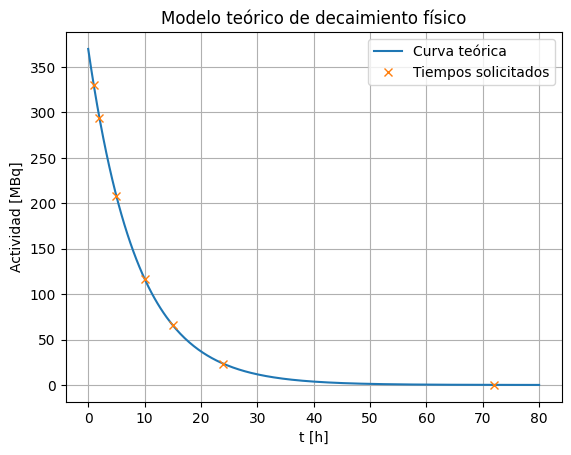

In [2]:
# Datos 3: 10 mCi/70 kg

lam= np.log(2)/6.02
Ao= 370 #MBq    
tiempos= [1,2,5,10,15,24,72]
x= []
for i in tiempos:
    A= Ao*np.exp(-lam*i)
    x.append(A)

t_continuo= np.linspace(0,80,300)
A_continuo= Ao*np.exp(-lam*t_continuo)
plt.figure()
plt.plot(t_continuo, A_continuo, label='Curva teórica')
plt.plot(tiempos, x, 'x', label='Tiempos solicitados')
plt.xlabel('t [h]')
plt.ylabel('Actividad [MBq]')
plt.title('Modelo teórico de decaimiento físico')
plt.legend()
plt.grid('on')
plt.show()

In [3]:
print(lam)

0.11514072766776501


# Mínimos cuadrados

In [4]:
datos= scipy.loadmat('Datos3.mat')
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'datos'])


In [5]:
a = datos['datos'][:, 1].flatten()
t = datos['datos'][:, 0].flatten()
N = len(t)

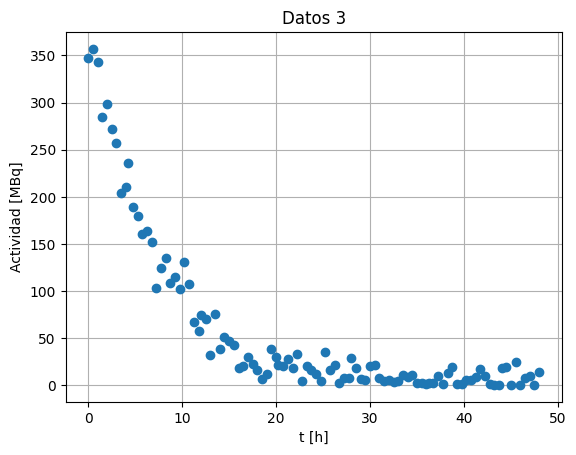

In [6]:
plt.plot(t, a, 'o')
plt.xlabel('t [h]')
plt.ylabel('Actividad [MBq]')
plt.title('Datos 3')
plt.grid();

### Linealizar los datos

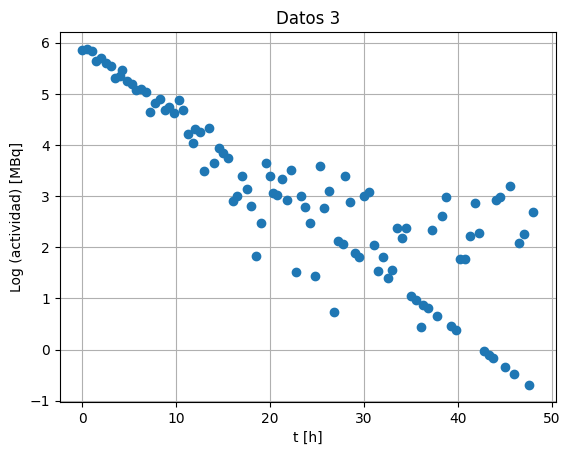

In [7]:
log= np.log(a)

plt.figure()
plt.plot(t,log,'o')
plt.xlabel("t [h]")
plt.ylabel("Log (actividad) [MBq]")
plt.title("Datos 3")
plt.grid("on");

In [8]:
N= len(t)
T= np.column_stack((np.ones(N), t))

Beta= np.linalg.pinv(T) @ log
print(f"Beta (Recta): intercepción= {Beta[0]:.6f} y pendiente= {Beta[1]:.6f}")


error_ml= np.linalg.norm(T@Beta-log) ** 2
T2= np.column_stack((np.ones(N), t, t**2))

BetaPlus= np.linalg.pinv(T2) @ log
print(f"BetaPlus (Cuadrático): {BetaPlus[0]}, {BetaPlus[1]} y {BetaPlus[2]}")


error_mc= np.linalg.norm(T2 @ BetaPlus - log) ** 2
print(f"SRC_ml= {error_ml:.6f} | SRC_mc = {error_mc:.6f}\n")


print("Matriz cruzada T'*T:")
print(T.T @ T)
print("\nMatriz cruzada T2'*T2:")
print(T2.T @ T2)

Beta (Recta): intercepción= 5.384185 y pendiente= -0.100236
BetaPlus (Cuadrático): 6.119590780152944, -0.1930540335397289 y 0.0019337018008880474
SRC_ml= 72.962179 | SRC_mc = 61.539477

Matriz cruzada T'*T:
[[  100.  2400.]
 [ 2400. 77169.]]

Matriz cruzada T2'*T2:
[[1.00000000e+02 2.40000000e+03 7.71690000e+04]
 [2.40000000e+03 7.71690000e+04 2.79136800e+06]
 [7.71690000e+04 2.79136800e+06 1.07692371e+08]]


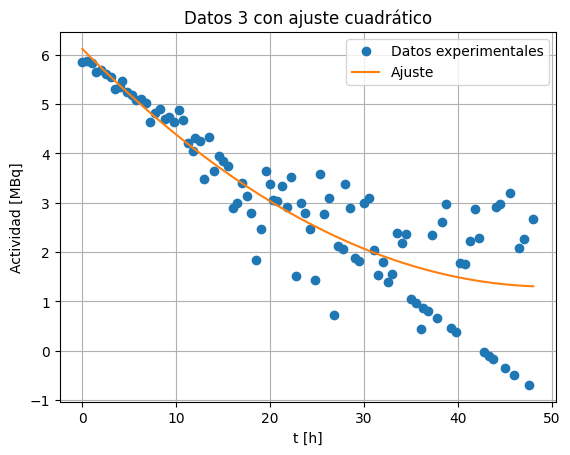

In [9]:
plt.figure
plt.plot(t,log,'o', label = "Datos experimentales")
plt.xlabel('t [h]')
plt.ylabel('Actividad [MBq]')
plt.title("Datos 3 con ajuste cuadrático")
plt.grid("on")
tn= np.linspace(0,48,100)
p_mc= BetaPlus[0] + BetaPlus[1] * tn + BetaPlus[2] * (tn ** 2)
plt.plot(tn,p_mc,label="Ajuste")
plt.legend()
plt.show()

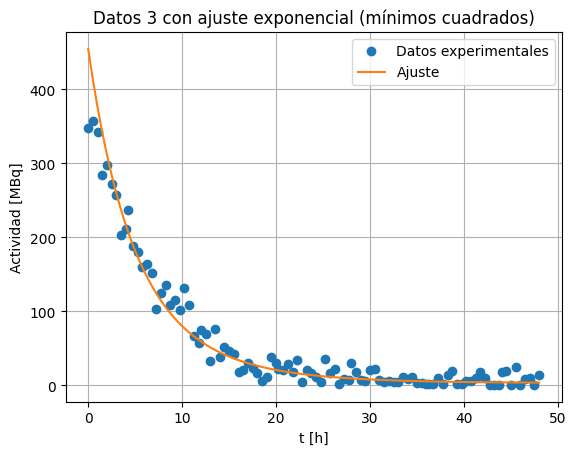

In [10]:
plt.plot(t, np.exp(log),'o', label="Datos experimentales")
plt.plot(tn, np.exp(p_mc), label="Ajuste")
plt.xlabel('t [h]')
plt.ylabel('Actividad [MBq]')
plt.title('Datos 3 con ajuste exponencial (mínimos cuadrados)')
plt.legend()
plt.grid();

# Vida media biológica

In [11]:
tmedio_b= np.log(0.5)/Beta[1]
p_evaluado= Beta[0] + Beta[1] * tmedio_b

print(f'vida media biológica: {tmedio_b:.2f} horas')

vida media biológica: 6.92 horas


In [12]:
p_mc_n= np.exp(p_mc)
max_val = np.max(p_mc_n)
half_val = max_val * 0.5
indice = np.argmin(np.abs(p_mc_n - half_val))
tiempo_mitad_a = t[indice]
valor_mitad = p_mc_n[indice]

print(f"Valor actividad máxima {max_val:.2f}")
print(f"El 50% de la actividad máxima para el ajuste cuadratico de datos 3 ({half_val:.2f}), por lo que el tiempo de vida promedio ocurre en t ≈ {tiempo_mitad_a}, con valor ≈ {valor_mitad:.2f}")

Valor actividad máxima 454.68
El 50% de la actividad máxima para el ajuste cuadratico de datos 3 (227.34), por lo que el tiempo de vida promedio ocurre en t ≈ 4.0, con valor ≈ 221.38


# Error de ajuste

In [13]:
a0_ajustada= p_mc[tn == 0]
a0_ajustada= np.exp(a0_ajustada)
a0_original= a[t == 0]
error= np.abs(a0_ajustada - a0_original)
error_relativo = (error / a0_original) * 100
print(f'Error absoluto en A0= {error}')
print(f'Error relativo en A0= {error_relativo:}%')

Error absoluto en A0= [107.11904259]
Error relativo en A0= [30.82034215]%
